# Module 3 · Assignment 2 — Unsupervised Learning
## Option B · Credit Card Behavioral Segmentation

Goal: segment credit card customers by behavior.  
I use the holdout only for stability checks, not for choosing the model.

---
## 1. Setup

In [1]:
# Keep this before importing sklearn on Windows/Anaconda.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import sys
import subprocess
import importlib.util
import importlib.metadata as importlib_metadata
from pathlib import Path


def version_tuple(version_text):
    parts = []
    for part in str(version_text).split("."):
        digits = "".join(ch for ch in part if ch.isdigit())
        if digits == "":
            break
        parts.append(int(digits))
    return tuple(parts) if parts else (0,)


def ensure_threadpoolctl():
    # Fixes a common Windows/Anaconda KMeans bug with older threadpoolctl versions.
    try:
        current = importlib_metadata.version("threadpoolctl")
    except importlib_metadata.PackageNotFoundError:
        current = "0"

    if version_tuple(current) < (3, 0):
        print("Upgrading threadpoolctl to avoid the Windows/Anaconda KMeans issue...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-U",
            "threadpoolctl>=3"
        ])

ensure_threadpoolctl()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
# sklearn KMeans is the main implementation.
# SimpleKMeans is only a local fallback in case an old Windows/Anaconda setup still fails.
class SimpleKMeans:
    """Small KMeans implementation with k-means++ initialization."""

    def __init__(self, n_clusters, n_init=10, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = int(n_clusters)
        self.n_init = int(n_init)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.random_state = int(random_state)
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = None

    def _init_centers(self, X, rng):
        n_samples = X.shape[0]
        centers = []
        first_idx = rng.integers(0, n_samples)
        centers.append(X[first_idx])

        for _ in range(1, self.n_clusters):
            distances = np.min(((X[:, None, :] - np.array(centers)[None, :, :]) ** 2).sum(axis=2), axis=1)
            total = distances.sum()
            if total == 0:
                next_idx = rng.integers(0, n_samples)
            else:
                probs = distances / total
                next_idx = rng.choice(n_samples, p=probs)
            centers.append(X[next_idx])
        return np.array(centers)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        best_inertia = np.inf
        best_labels = None
        best_centers = None
        best_iter = 0

        base_rng = np.random.default_rng(self.random_state)
        seeds = base_rng.integers(0, 1_000_000, size=self.n_init)

        for seed in seeds:
            rng = np.random.default_rng(int(seed))
            centers = self._init_centers(X, rng)

            for i in range(self.max_iter):
                distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
                labels = distances.argmin(axis=1)

                new_centers = centers.copy()
                for k in range(self.n_clusters):
                    mask = labels == k
                    if mask.any():
                        new_centers[k] = X[mask].mean(axis=0)
                    else:
                        new_centers[k] = X[rng.integers(0, X.shape[0])]

                shift = np.sqrt(((centers - new_centers) ** 2).sum())
                centers = new_centers
                if shift < self.tol:
                    break

            distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = distances.argmin(axis=1)
            inertia = distances[np.arange(X.shape[0]), labels].sum()

            if inertia < best_inertia:
                best_inertia = inertia
                best_labels = labels
                best_centers = centers
                best_iter = i + 1

        self.cluster_centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = float(best_inertia)
        self.n_iter_ = int(best_iter)
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        distances = ((X[:, None, :] - self.cluster_centers_[None, :, :]) ** 2).sum(axis=2)
        return distances.argmin(axis=1)


USE_SIMPLE_KMEANS = False
KMEANS_BACKEND = "sklearn"


def fit_kmeans(X, n_clusters, n_init=20, random_state=42, max_iter=300):
    """Fit KMeans with sklearn when possible, otherwise use a small fallback."""
    global USE_SIMPLE_KMEANS, KMEANS_BACKEND

    if not USE_SIMPLE_KMEANS:
        try:
            from sklearn.cluster import KMeans
            model = KMeans(
                n_clusters=n_clusters,
                n_init=n_init,
                max_iter=max_iter,
                random_state=random_state
            )
            labels = model.fit_predict(X)
            KMEANS_BACKEND = "sklearn"
            return model, labels
        except Exception:
            print("Using SimpleKMeans fallback. In a normal environment, sklearn KMeans should run after upgrading threadpoolctl.")
            USE_SIMPLE_KMEANS = True
            KMEANS_BACKEND = "simple"

    model = SimpleKMeans(
        n_clusters=n_clusters,
        n_init=n_init,
        max_iter=max_iter,
        random_state=random_state
    )
    labels = model.fit_predict(X)
    KMEANS_BACKEND = "simple"
    return model, labels

---
## 2. Load data

In [4]:
# Install kagglehub only if it is missing.
def ensure_package(package_name):
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

try:
    ensure_package("kagglehub")
    import kagglehub
except Exception as e:
    kagglehub = None
    print("kagglehub is not available. If needed, place CC GENERAL.csv near this notebook.")

DATA_PATH = None  # Example: DATA_PATH = "CC GENERAL.csv"
DATASET_SLUG = "arjunbhasin2013/ccdata"


def find_credit_card_csv(folder):
    folder = Path(folder)
    csv_files = list(folder.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV file found in: " + str(folder))
    preferred = [p for p in csv_files if "CC" in p.name.upper() or "GENERAL" in p.name.upper()]
    return preferred[0] if preferred else csv_files[0]

if DATA_PATH is not None:
    csv_path = Path(DATA_PATH)
elif kagglehub is not None:
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
    csv_path = find_credit_card_csv(dataset_path)
else:
    csv_path = find_credit_card_csv(Path.cwd())

raw_df = pd.read_csv(csv_path)
print("Loaded file:", csv_path)
print("Shape:", raw_df.shape)
display(raw_df.head())

Loaded file: C:\Users\netaf\.cache\kagglehub\datasets\arjunbhasin2013\ccdata\versions\1\CC GENERAL.csv
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


---
## 3. EDA
Short checks before clustering. The main things I care about are missing values, skewness, scale, and redundant features.

In [5]:
# Basic structure
info_table = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().mean() * 100).round(2),
    "n_unique": raw_df.nunique()
})

display(info_table)

,dtype,missing,missing_pct,n_unique
CUST_ID,object,0,0.00,8950
BALANCE,float64,0,0.00,8871
BALANCE_FREQUENCY,float64,0,0.00,43
PURCHASES,float64,0,0.00,6203
ONEOFF_PURCHASES,float64,0,0.00,4014
INSTALLMENTS_PURCHASES,float64,0,0.00,4452
CASH_ADVANCE,float64,0,0.00,4323
PURCHASES_FREQUENCY,float64,0,0.00,47
ONEOFF_PURCHASES_FREQUENCY,float64,0,0.00,47
PURCHASES_INSTALLMENTS_FREQUENCY,float64,0,0.00,47


In [6]:
# Numeric summary with skewness indicators
numeric_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()

summary = raw_df[numeric_cols].describe().T
summary["missing"] = raw_df[numeric_cols].isna().sum()
summary["skew"] = raw_df[numeric_cols].skew(numeric_only=True).round(2)
summary["max_to_mean"] = (summary["max"] / summary["mean"].replace(0, np.nan)).round(1)
summary = summary[["count", "missing", "mean", "50%", "std", "min", "max", "skew", "max_to_mean"]]

display(summary.round(2))

,count,missing,mean,50%,std,min,max,skew,max_to_mean
BALANCE,8950.0,0,1564.47,873.39,2081.53,0.00,19043.14,2.39,12.2
BALANCE_FREQUENCY,8950.0,0,0.88,1.00,0.24,0.00,1.00,-2.02,1.1
PURCHASES,8950.0,0,1003.20,361.28,2136.63,0.00,49039.57,8.14,48.9
ONEOFF_PURCHASES,8950.0,0,592.44,38.00,1659.89,0.00,40761.25,10.05,68.8
INSTALLMENTS_PURCHASES,8950.0,0,411.07,89.00,904.34,0.00,22500.00,7.30,54.7
CASH_ADVANCE,8950.0,0,978.87,0.00,2097.16,0.00,47137.21,5.17,48.2
PURCHASES_FREQUENCY,8950.0,0,0.49,0.50,0.40,0.00,1.00,0.06,2.0
ONEOFF_PURCHASES_FREQUENCY,8950.0,0,0.20,0.08,0.30,0.00,1.00,1.54,4.9
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0,0.36,0.17,0.40,0.00,1.00,0.51,2.7
CASH_ADVANCE_FREQUENCY,8950.0,0,0.14,0.00,0.20,0.00,1.50,1.83,11.1


In [7]:
# Data quality checks for frequency-like fields
freq_cols = [c for c in numeric_cols if "FREQUENCY" in c.upper() or c.upper() == "PRC_FULL_PAYMENT"]

freq_quality = []
for col in freq_cols:
    s = raw_df[col].dropna()
    freq_quality.append({
        "feature": col,
        "min": s.min(),
        "max": s.max(),
        "below_0_count": int((s < 0).sum()),
        "above_1_count": int((s > 1).sum()),
        "above_1_pct": round((s > 1).mean() * 100, 2)
    })

freq_quality = pd.DataFrame(freq_quality)
display(freq_quality)

# Modeling copy: cap impossible frequency values at 1.0.
# In this dataset this mainly affects CASH_ADVANCE_FREQUENCY and only a few rows.
modeling_df = raw_df.copy()
cap_rows = []
for col in freq_cols:
    if col in modeling_df.columns:
        above_mask = modeling_df[col] > 1
        n_above = int(above_mask.sum())
        if n_above > 0:
            modeling_df.loc[above_mask, col] = 1.0
        cap_rows.append({"feature": col, "capped_rows": n_above})

cap_summary = pd.DataFrame(cap_rows)
display(cap_summary[cap_summary["capped_rows"] > 0])

,feature,min,max,below_0_count,above_1_count,above_1_pct
0,BALANCE_FREQUENCY,0.0,1.0,0,0,0.00
1,PURCHASES_FREQUENCY,0.0,1.0,0,0,0.00
2,ONEOFF_PURCHASES_FREQUENCY,0.0,1.0,0,0,0.00
3,PURCHASES_INSTALLMENTS_FREQUENCY,0.0,1.0,0,0,0.00
4,CASH_ADVANCE_FREQUENCY,0.0,1.5,0,8,0.09
5,PRC_FULL_PAYMENT,0.0,1.0,0,0,0.00


,feature,capped_rows
4,CASH_ADVANCE_FREQUENCY,8


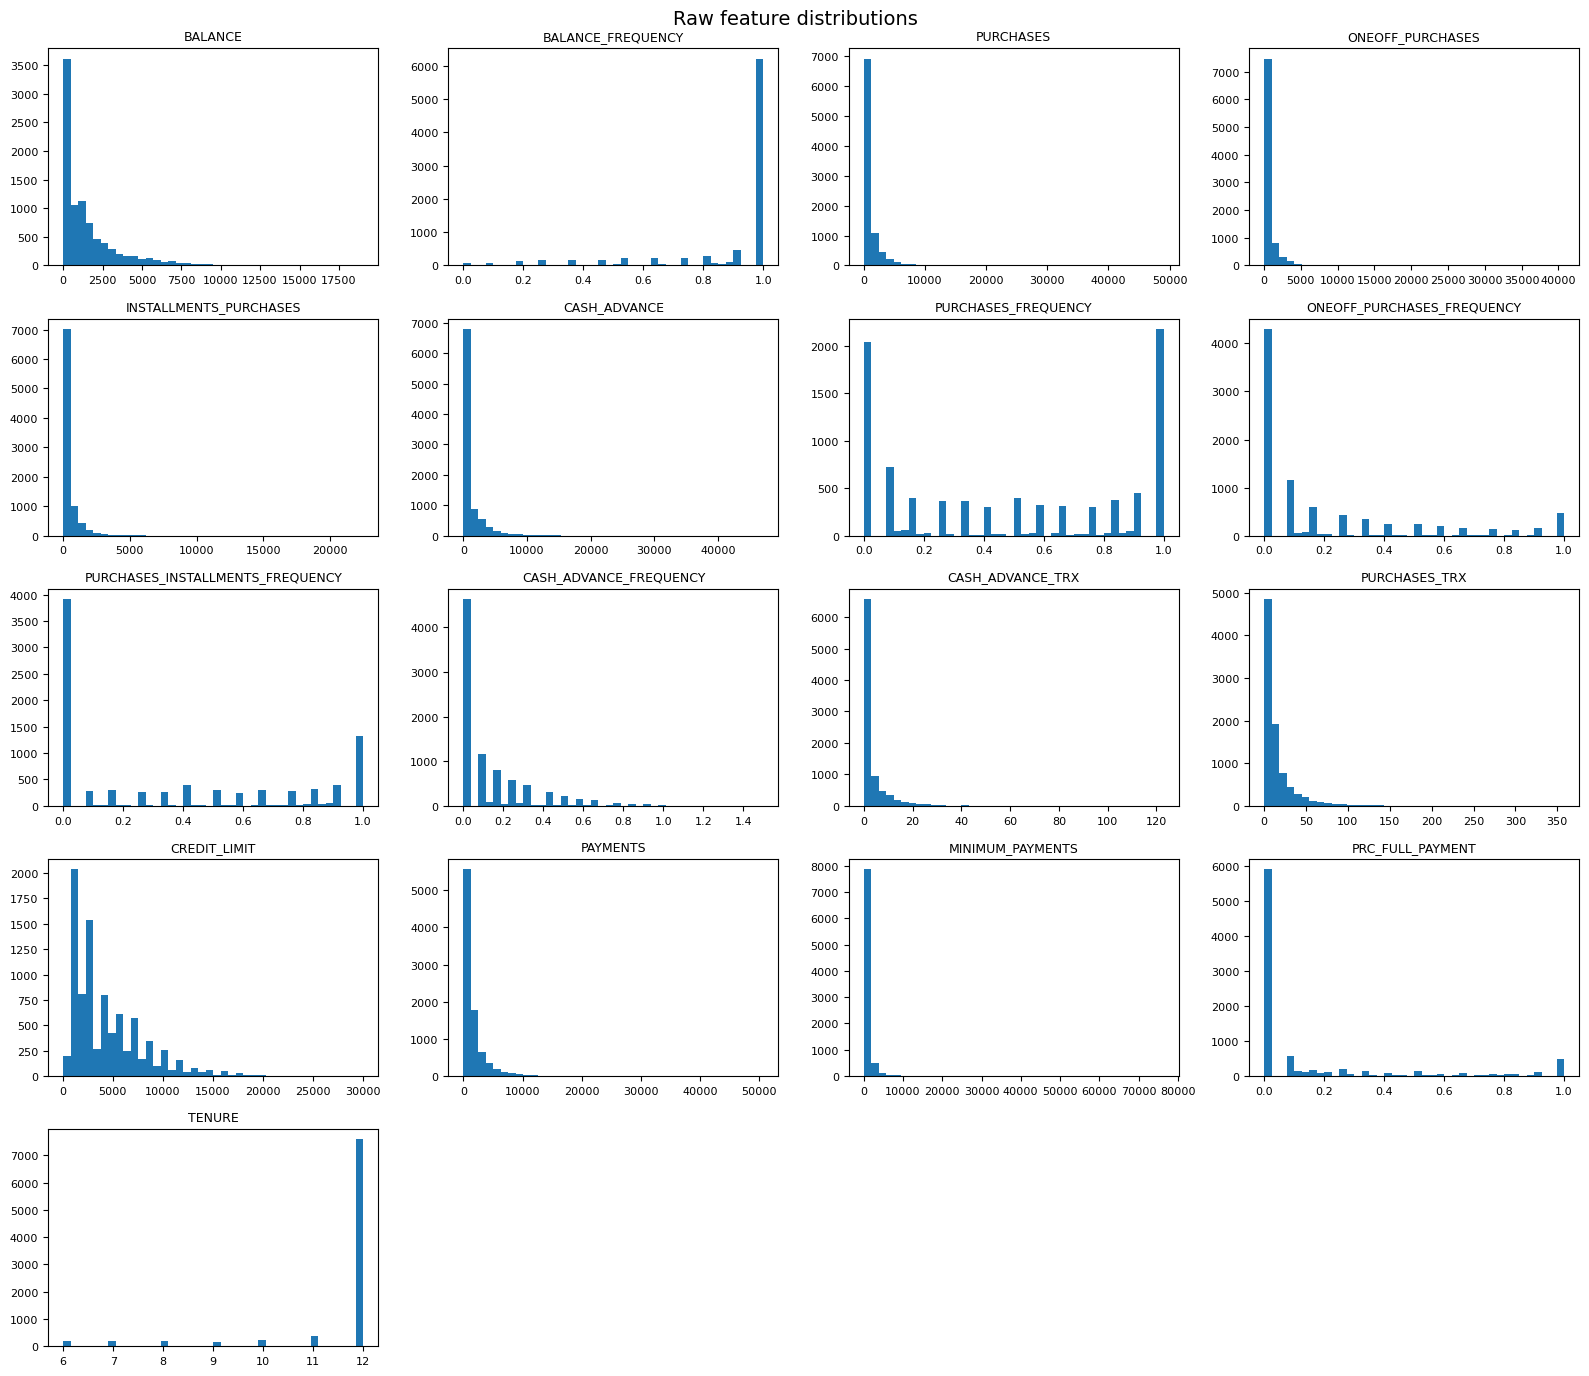

In [8]:
# Distribution grid: one figure, many plots.
def plot_hist_grid(df, cols, bins=40, ncols=4, title="Distributions"):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins)
        ax.set_title(col, fontsize=9)
        ax.tick_params(axis="both", labelsize=8)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_hist_grid(raw_df, numeric_cols, title="Raw feature distributions")

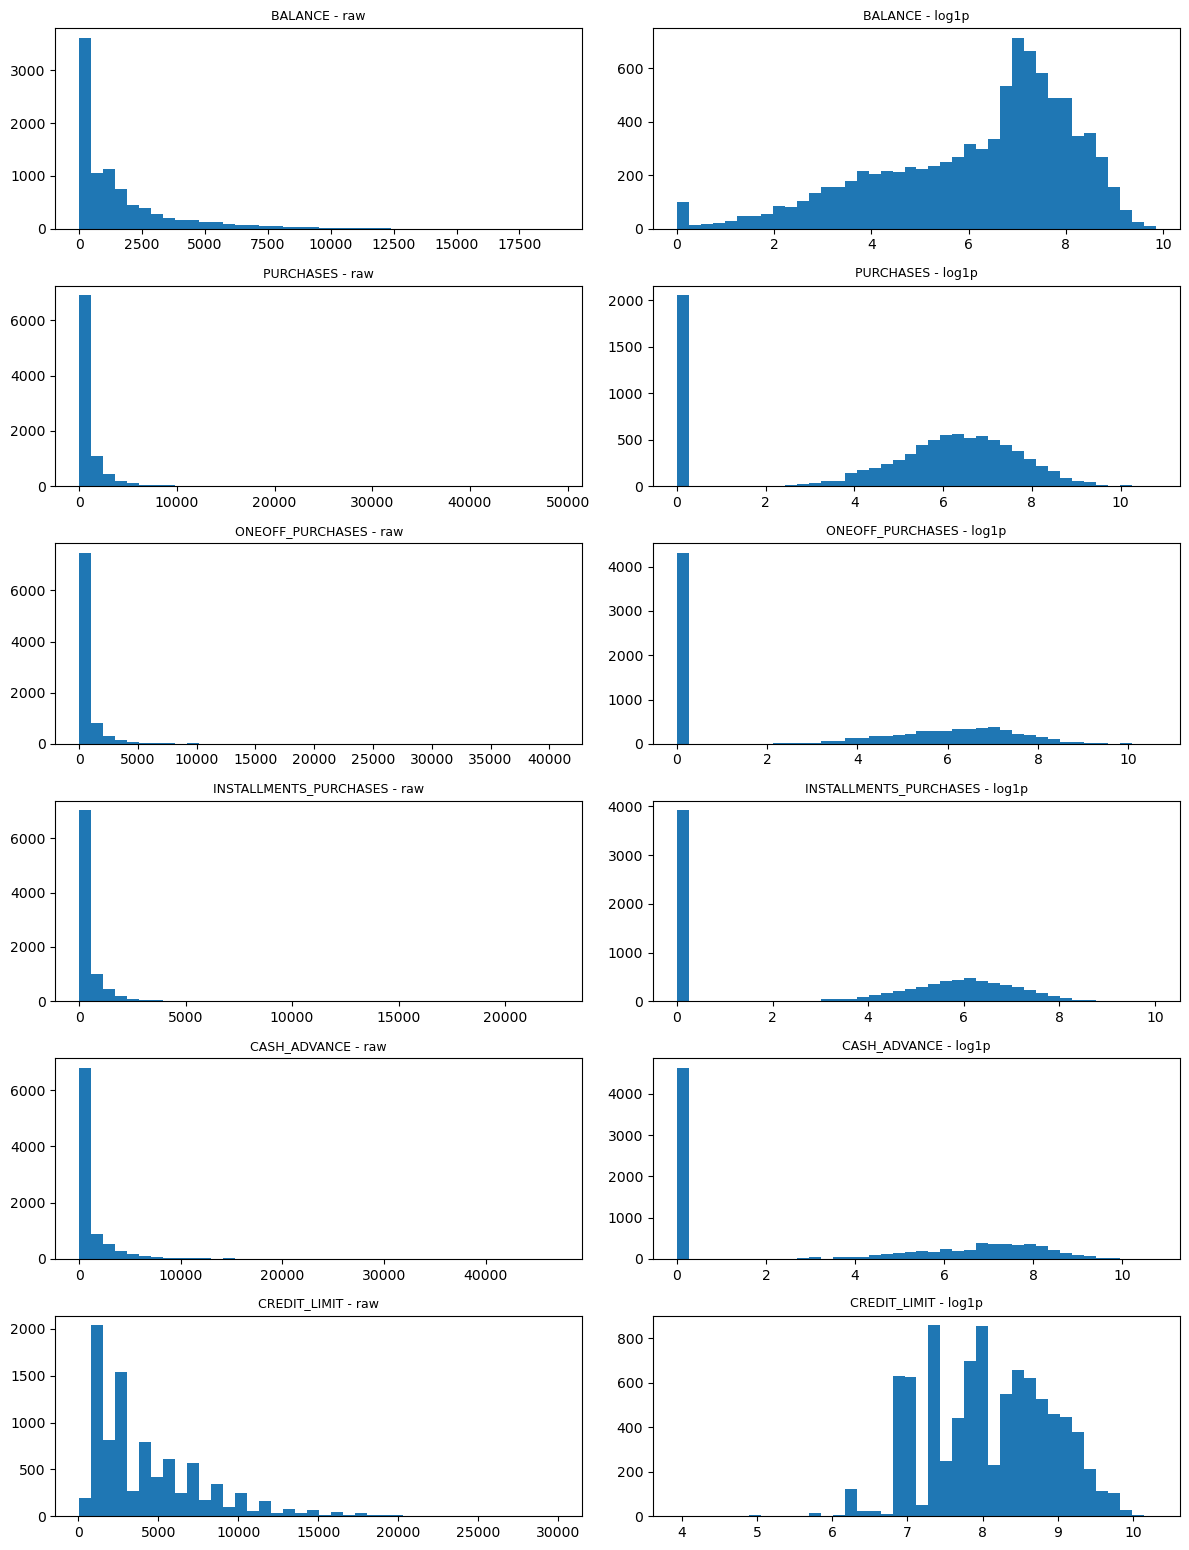

In [9]:
# Before/after log view for the most skewed money/count columns.
log_candidate_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
    "PURCHASES_TRX", "CASH_ADVANCE_TRX"
]
log_candidate_cols = [c for c in log_candidate_cols if c in raw_df.columns]

n = min(6, len(log_candidate_cols))
fig, axes = plt.subplots(n, 2, figsize=(12, 2.6 * n))
if n == 1:
    axes = np.array([axes])

for i, col in enumerate(log_candidate_cols[:n]):
    raw_values = raw_df[col].dropna().clip(lower=0)
    axes[i, 0].hist(raw_values, bins=40)
    axes[i, 0].set_title(col + " - raw", fontsize=9)

    axes[i, 1].hist(np.log1p(raw_values), bins=40)
    axes[i, 1].set_title(col + " - log1p", fontsize=9)

plt.tight_layout()
plt.show()

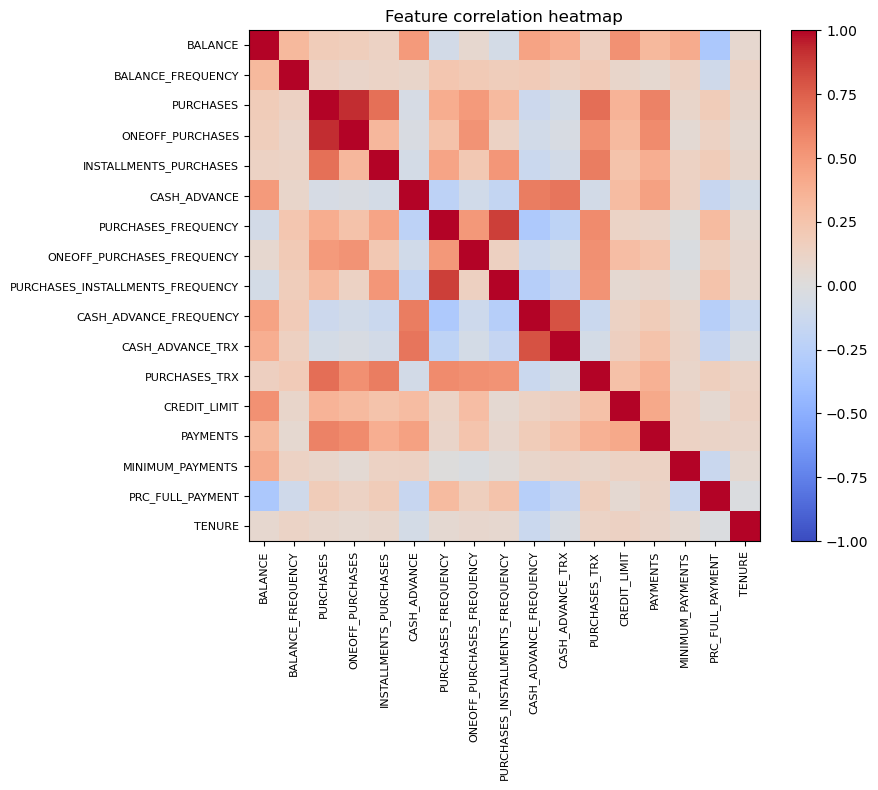

,feature_1,feature_2,abs_corr
0,PURCHASES,ONEOFF_PURCHASES,0.916845
1,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.862934
2,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.801188
3,PURCHASES,PURCHASES_TRX,0.689561
4,PURCHASES,INSTALLMENTS_PURCHASES,0.679896
5,CASH_ADVANCE,CASH_ADVANCE_TRX,0.656498
6,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.630226
7,INSTALLMENTS_PURCHASES,PURCHASES_TRX,0.628108
8,PURCHASES,PAYMENTS,0.603264
9,PURCHASES_FREQUENCY,PURCHASES_TRX,0.568430


In [10]:
# Correlation heatmap without seaborn.
corr = modeling_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

# Strongest absolute correlations
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False).reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
display(high_corr_pairs.head(15))

---
## 4. Feature set and holdout
No target exists here. The holdout is only for stability, not for model selection.

In [11]:
# Identifier is not behavior.
id_columns = [col for col in modeling_df.columns if col.upper() == "CUST_ID"]
feature_cols_full = [c for c in numeric_cols if c not in id_columns]

# Reduced set: avoid counting the same behavior too many times in Euclidean distance.
# PURCHASES = ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES in this dataset, so I keep the components.
# Transaction counts are useful, but also highly related to amount/frequency; I keep the main frequencies instead.
drop_redundant = ["PURCHASES", "PURCHASES_TRX", "CASH_ADVANCE_TRX"]
feature_cols_reduced = [c for c in feature_cols_full if c not in drop_redundant]

feature_choice = pd.DataFrame({
    "full_features": pd.Series(feature_cols_full),
    "reduced_features": pd.Series(feature_cols_reduced)
})
display(feature_choice)

customer_ids = modeling_df[id_columns[0]].copy() if id_columns else pd.Series(modeling_df.index, name="customer_id")
X_all = modeling_df[feature_cols_full].copy()

X_main_raw, X_holdout_raw, ids_main, ids_holdout = train_test_split(
    X_all,
    customer_ids,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Main sample:", X_main_raw.shape)
print("Holdout sample:", X_holdout_raw.shape)

,full_features,reduced_features
0,BALANCE,BALANCE
1,BALANCE_FREQUENCY,BALANCE_FREQUENCY
2,PURCHASES,ONEOFF_PURCHASES
3,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
4,INSTALLMENTS_PURCHASES,CASH_ADVANCE
5,CASH_ADVANCE,PURCHASES_FREQUENCY
6,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY
7,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY
8,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY
9,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT


Main sample: (7160, 17)
Holdout sample: (1790, 17)


---
## 5. Preprocessing candidates
I compare the original scaling against a log-based version. This is the main improvement because many features are strongly right-skewed.

In [12]:
log_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
    "PURCHASES_TRX", "CASH_ADVANCE_TRX"
]


def prepare_data(X_train_raw, X_holdout_raw, selected_features, use_log=False):
    """Fit imputer/scaler on the main sample and transform main + holdout."""
    X_train = X_train_raw[selected_features].copy()
    X_holdout = X_holdout_raw[selected_features].copy()

    if use_log:
        for col in log_cols:
            if col in selected_features:
                X_train[col] = np.log1p(X_train[col].clip(lower=0))
                X_holdout[col] = np.log1p(X_holdout[col].clip(lower=0))

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=selected_features,
        index=X_train.index
    )
    X_holdout_imputed = pd.DataFrame(
        imputer.transform(X_holdout),
        columns=selected_features,
        index=X_holdout.index
    )

    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_holdout_scaled = scaler.transform(X_holdout_imputed)

    return {
        "features": selected_features,
        "use_log": use_log,
        "imputer": imputer,
        "scaler": scaler,
        "main_imputed": X_train_imputed,
        "holdout_imputed": X_holdout_imputed,
        "main_scaled": X_train_scaled,
        "holdout_scaled": X_holdout_scaled
    }

preprocessing_setups = {
    "full_scaled": prepare_data(X_main_raw, X_holdout_raw, feature_cols_full, use_log=False),
    "full_log_scaled": prepare_data(X_main_raw, X_holdout_raw, feature_cols_full, use_log=True),
    "reduced_log_scaled": prepare_data(X_main_raw, X_holdout_raw, feature_cols_reduced, use_log=True)
}

print("Prepared setups:", list(preprocessing_setups.keys()))

Prepared setups: ['full_scaled', 'full_log_scaled', 'reduced_log_scaled']


---
## 6. Scaling check
This is not a model choice. It only shows how much the distance space changes after scaling.

In [13]:
def cluster_size_string(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    shares = (counts / counts.sum() * 100).round(1)
    return ", ".join([f"{idx}: {counts.loc[idx]} ({shares.loc[idx]}%)" for idx in counts.index])

K_FOR_SCALING_DEMO = 4
full_setup = preprocessing_setups["full_scaled"]

# Imputed but unscaled matrix.
X_unscaled_demo = full_setup["main_imputed"].values
X_scaled_demo = full_setup["main_scaled"]

model_unscaled, labels_unscaled = fit_kmeans(X_unscaled_demo, K_FOR_SCALING_DEMO, n_init=20, random_state=RANDOM_STATE)
model_scaled, labels_scaled = fit_kmeans(X_scaled_demo, K_FOR_SCALING_DEMO, n_init=20, random_state=RANDOM_STATE)

scaling_demo = pd.DataFrame({
    "version": ["unscaled", "scaled"],
    "silhouette_in_own_space": [
        silhouette_score(X_unscaled_demo, labels_unscaled),
        silhouette_score(X_scaled_demo, labels_scaled)
    ],
    "cluster_sizes": [cluster_size_string(labels_unscaled), cluster_size_string(labels_scaled)]
})

display(scaling_demo)
print("Important: the two Silhouette values are not directly comparable because they are measured in different distance spaces.")
print("The unscaled result can look better only because high-value money columns dominate Euclidean distance.")
print("KMeans backend used:", KMEANS_BACKEND)

,version,silhouette_in_own_space,cluster_sizes
0,unscaled,0.465344,"0: 5155 (72.0%), 1: 124 (1.7%), 2: 1851 (25.9%..."
1,scaled,0.198413,"0: 316 (4.4%), 1: 2709 (37.8%), 2: 3194 (44.6%..."


Important: the two Silhouette values are not directly comparable because they are measured in different distance spaces.
The unscaled result can look better only because high-value money columns dominate Euclidean distance.
KMeans backend used: sklearn


---
## 7. Compare preprocessing setups
Same algorithm, same k range. I check if log-transform and feature reduction make the structure cleaner.

In [14]:
def estimate_elbow_k(k_values, inertias):
    """Estimate elbow as the point farthest from the line between first and last inertia."""
    k_arr = np.array(list(k_values), dtype=float)
    inertia_arr = np.array(inertias, dtype=float)

    x = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    y = (inertia_arr - inertia_arr.min()) / (inertia_arr.max() - inertia_arr.min())
    points = np.column_stack([x, y])
    start = points[0]
    end = points[-1]
    line = end - start
    distances = np.abs(np.cross(line, start - points)) / np.sqrt((line ** 2).sum())
    return int(k_arr[distances.argmax()])


def evaluate_kmeans_grid(X_scaled, k_values, n_init=20):
    rows = []
    for k in k_values:
        model, labels = fit_kmeans(X_scaled, n_clusters=k, n_init=n_init, random_state=RANDOM_STATE)
        counts = pd.Series(labels).value_counts(normalize=True)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "largest_cluster_share": counts.max(),
            "smallest_cluster_share": counts.min()
        })
    result = pd.DataFrame(rows)
    result["elbow_k"] = estimate_elbow_k(result["k"], result["inertia"])
    return result

k_values = list(range(2, 8))
setup_results = {}
setup_summary_rows = []

for setup_name, setup in preprocessing_setups.items():
    grid = evaluate_kmeans_grid(setup["main_scaled"], k_values, n_init=20)
    setup_results[setup_name] = grid

    best_row = grid.loc[grid["silhouette"].idxmax()]
    setup_summary_rows.append({
        "setup": setup_name,
        "n_features": len(setup["features"]),
        "best_silhouette_k": int(best_row["k"]),
        "best_silhouette": float(best_row["silhouette"]),
        "largest_cluster_at_best_k": float(best_row["largest_cluster_share"]),
        "elbow_k": int(grid["elbow_k"].iloc[0])
    })

setup_summary = pd.DataFrame(setup_summary_rows).round(4)
display(setup_summary)

,setup,n_features,best_silhouette_k,best_silhouette,largest_cluster_at_best_k,elbow_k
0,full_scaled,17,3,0.2515,0.6863,4
1,full_log_scaled,17,2,0.2536,0.6478,3
2,reduced_log_scaled,14,4,0.2214,0.3665,4


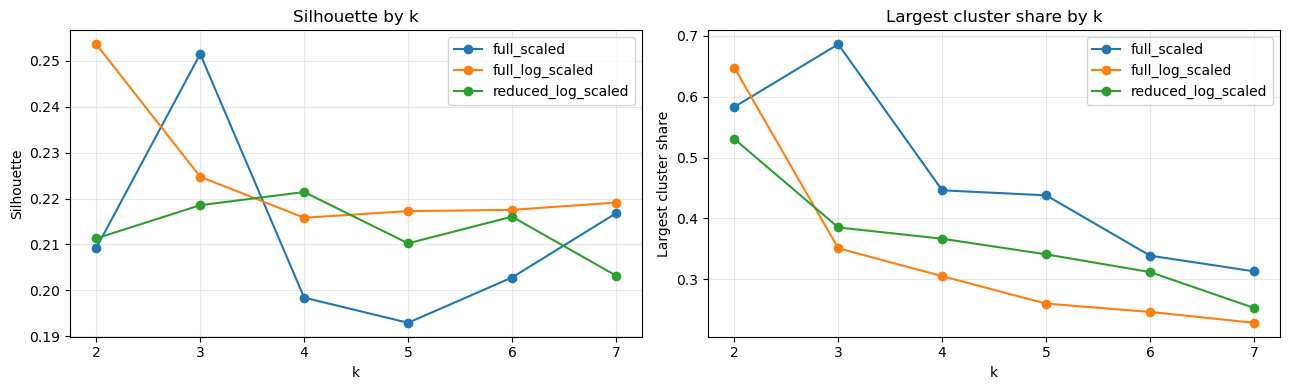

In [15]:
# One clean comparison figure for the preprocessing setups.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for setup_name, grid in setup_results.items():
    axes[0].plot(grid["k"], grid["silhouette"], marker="o", label=setup_name)
    axes[1].plot(grid["k"], grid["largest_cluster_share"], marker="o", label=setup_name)

axes[0].set_title("Silhouette by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Largest cluster share by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Largest cluster share")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

**Preprocessing choice.**  
`full_log_scaled` has a slightly higher Silhouette at `k=2`, but `k=2` is too coarse for useful customer actions. I use `reduced_log_scaled` because it handles skewness, reduces duplicate distance weighting, and gives more balanced segments.

In [16]:
# Final preprocessing choice.
# I choose this setup because it handles skewness and reduces duplicate distance weighting.
FINAL_SETUP_NAME = "reduced_log_scaled"
setup = preprocessing_setups[FINAL_SETUP_NAME]

X_main_scaled = setup["main_scaled"]
X_holdout_scaled = setup["holdout_scaled"]
X_main_imputed = setup["main_imputed"]
X_holdout_imputed = setup["holdout_imputed"]
feature_cols = setup["features"]

print("Final preprocessing:", FINAL_SETUP_NAME)
print("Features used:", len(feature_cols))
print(feature_cols)

Final preprocessing: reduced_log_scaled
Features used: 14
['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


---
## 8. PCA
PCA is for visualization and interpretation, not proof.

,component,explained_variance_ratio,cumulative_variance
0,1,0.2759,0.2759
1,2,0.2345,0.5104
2,3,0.1102,0.6206
3,4,0.0783,0.6988
4,5,0.0778,0.7766
5,6,0.0578,0.8344
6,7,0.0443,0.8786
7,8,0.0372,0.9158
8,9,0.0307,0.9465
9,10,0.0171,0.9636


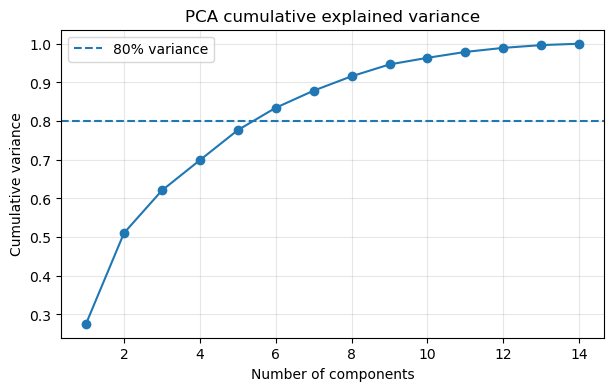

In [17]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_main_scaled)

pca_table = pd.DataFrame({
    "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_)
})

display(pca_table.head(10).round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pca_table["component"], pca_table["cumulative_variance"], marker="o")
ax.axhline(0.80, linestyle="--", label="80% variance")
ax.set_title("PCA cumulative explained variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative variance")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [18]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords_main = pca_2.fit_transform(X_main_scaled)
coords_holdout = pca_2.transform(X_holdout_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

loadings_summary = pd.concat([
    loadings["PC1"].abs().sort_values(ascending=False).head(8).rename("PC1_abs_loading"),
    loadings["PC2"].abs().sort_values(ascending=False).head(8).rename("PC2_abs_loading")
], axis=1)

display(loadings_summary.round(3))

,PC1_abs_loading,PC2_abs_loading
PURCHASES_FREQUENCY,0.412,0.236
CASH_ADVANCE,0.399,NaN
INSTALLMENTS_PURCHASES,0.385,NaN
PURCHASES_INSTALLMENTS_FREQUENCY,0.376,NaN
CASH_ADVANCE_FREQUENCY,0.346,NaN
PRC_FULL_PAYMENT,0.268,NaN
BALANCE,0.265,0.420
MINIMUM_PAYMENTS,0.226,0.353
BALANCE_FREQUENCY,NaN,0.370
PAYMENTS,NaN,0.356


---
## 9. Choose k
I compare Elbow, Silhouette, cluster sizes, and business usefulness. I do not use the holdout for this choice.

In [19]:
k_results = setup_results[FINAL_SETUP_NAME].copy()
ELBOW_K = int(k_results["elbow_k"].iloc[0])
BEST_SILHOUETTE_K = int(k_results.loc[k_results["silhouette"].idxmax(), "k"])

# I keep k=4 in the comparison because it often splits the broad "everyone else" group.
k_to_compare = sorted(set([BEST_SILHOUETTE_K, ELBOW_K, 3, 4]))
k_to_compare = [k for k in k_to_compare if k in k_values]

comparison_rows = []
labels_by_k = {}
models_by_k = {}

for k in k_to_compare:
    model, labels = fit_kmeans(X_main_scaled, n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels_by_k[k] = labels
    models_by_k[k] = model
    counts = pd.Series(labels).value_counts(normalize=True).sort_index()
    comparison_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_main_scaled, labels),
        "largest_cluster_share": counts.max(),
        "smallest_cluster_share": counts.min(),
        "cluster_sizes": cluster_size_string(labels)
    })

k_decision_table = pd.DataFrame(comparison_rows).round(4)
display(k_results.round(4))
display(k_decision_table)

print("Elbow k:", ELBOW_K)
print("Best Silhouette k:", BEST_SILHOUETTE_K)

,k,inertia,silhouette,largest_cluster_share,smallest_cluster_share,elbow_k
0,2,79461.7486,0.2113,0.5304,0.4696,4
1,3,66715.8650,0.2185,0.3851,0.2792,4
2,4,59745.8691,0.2214,0.3665,0.1479,4
3,5,55406.1895,0.2102,0.3408,0.1204,4
4,6,51567.2136,0.2160,0.3116,0.0641,4
5,7,48034.1916,0.2032,0.2527,0.0627,4


,k,silhouette,largest_cluster_share,smallest_cluster_share,cluster_sizes
0,3,0.2185,0.3851,0.2792,"0: 2757 (38.5%), 1: 1999 (27.9%), 2: 2404 (33.6%)"
1,4,0.2212,0.3662,0.1486,"0: 2622 (36.6%), 1: 1839 (25.7%), 2: 1064 (14...."


Elbow k: 4
Best Silhouette k: 4


In [20]:
# Final k.
# In this run both Elbow and Silhouette point to k=4.
# Business-wise, k=4 also avoids one broad "everyone else" segment.
if ELBOW_K == BEST_SILHOUETTE_K:
    SELECTED_K = BEST_SILHOUETTE_K
else:
    row_best = k_decision_table[k_decision_table["k"] == BEST_SILHOUETTE_K].iloc[0]
    row_4 = k_decision_table[k_decision_table["k"] == 4].iloc[0] if 4 in k_decision_table["k"].values else None

    if row_4 is not None and row_4["largest_cluster_share"] < row_best["largest_cluster_share"] and (row_best["silhouette"] - row_4["silhouette"] <= 0.03):
        SELECTED_K = 4
    else:
        SELECTED_K = BEST_SILHOUETTE_K

kmeans_final = models_by_k.get(SELECTED_K)
kmeans_labels = labels_by_k.get(SELECTED_K)

if kmeans_final is None:
    kmeans_final, kmeans_labels = fit_kmeans(X_main_scaled, n_clusters=SELECTED_K, n_init=50, random_state=RANDOM_STATE)

final_silhouette = silhouette_score(X_main_scaled, kmeans_labels)
cluster_counts = pd.Series(kmeans_labels, name="cluster").value_counts().sort_index()
cluster_shares = (cluster_counts / cluster_counts.sum()).round(4)

cluster_size_table = pd.DataFrame({
    "count": cluster_counts,
    "share": cluster_shares
})

print("Selected k:", SELECTED_K)
print("Reason: Elbow k =", ELBOW_K, ", best Silhouette k =", BEST_SILHOUETTE_K, ", and the cluster sizes are more balanced.")
print("Final Silhouette:", round(final_silhouette, 4))
display(cluster_size_table)

Selected k: 4
Reason: Elbow k = 4 , best Silhouette k = 4 , and the cluster sizes are more balanced.
Final Silhouette: 0.2212


,count,share
cluster,,
0,2622,0.3662
1,1839,0.2568
2,1064,0.1486
3,1635,0.2284


In [21]:
# Average silhouette by cluster helps find weak segments.
sample_sil = silhouette_samples(X_main_scaled, kmeans_labels)
sil_by_cluster = pd.DataFrame({
    "cluster": kmeans_labels,
    "sample_silhouette": sample_sil
}).groupby("cluster").agg(
    avg_silhouette=("sample_silhouette", "mean"),
    min_silhouette=("sample_silhouette", "min"),
    pct_negative=("sample_silhouette", lambda x: (x < 0).mean())
).round(4)

display(sil_by_cluster)

,avg_silhouette,min_silhouette,pct_negative
cluster,,,
0,0.3058,-0.0054,0.0008
1,0.1600,-0.0455,0.0718
2,0.1198,-0.1234,0.1945
3,0.2202,-0.0118,0.0061


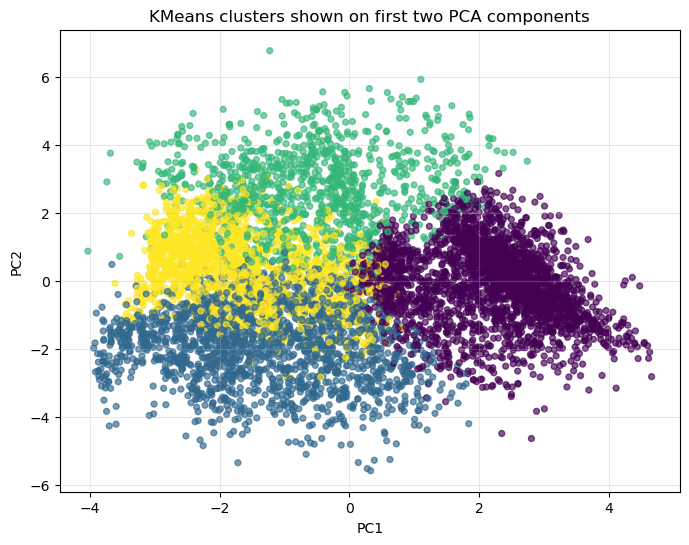

In [22]:
# PCA visualization of final KMeans clusters.
pca_plot_df = pd.DataFrame({
    "PC1": coords_main[:, 0],
    "PC2": coords_main[:, 1],
    "cluster": kmeans_labels
})

plt.figure(figsize=(8, 6))
plt.scatter(pca_plot_df["PC1"], pca_plot_df["PC2"], c=pca_plot_df["cluster"], alpha=0.65, s=18)
plt.title("KMeans clusters shown on first two PCA components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

---
## 10. Second approach: Ward hierarchical clustering
I use a sample for speed. The goal is not to match labels perfectly, but to see whether another distance-based method finds a similar structure.

In [23]:
HIERARCHICAL_SAMPLE_SIZE = min(2500, X_main_scaled.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
hier_positions = rng.choice(np.arange(X_main_scaled.shape[0]), size=HIERARCHICAL_SAMPLE_SIZE, replace=False)

X_hier = X_main_scaled[hier_positions]
kmeans_labels_hier_sample = kmeans_labels[hier_positions]

hier_model = AgglomerativeClustering(n_clusters=SELECTED_K, linkage="ward")
hier_labels = hier_model.fit_predict(X_hier)

hier_silhouette = silhouette_score(X_hier, hier_labels)
hier_vs_kmeans_ari = adjusted_rand_score(kmeans_labels_hier_sample, hier_labels)

hier_compare = pd.DataFrame({
    "metric": ["Ward silhouette", "ARI: Ward vs KMeans"],
    "value": [hier_silhouette, hier_vs_kmeans_ari]
})
display(hier_compare.round(4))

# Cross-tab shows where the methods disagree.
hier_crosstab = pd.crosstab(
    pd.Series(kmeans_labels_hier_sample, name="KMeans"),
    pd.Series(hier_labels, name="Ward"),
    normalize="index"
).round(3)

display(hier_crosstab)

,metric,value
0,Ward silhouette,0.1787
1,ARI: Ward vs KMeans,0.5683


Ward,0,1,2,3
KMeans,,,,
0,0.127,0.828,0.029,0.015
1,0.945,0.033,0.009,0.013
2,0.142,0.045,0.768,0.045
3,0.203,0.038,0.093,0.666


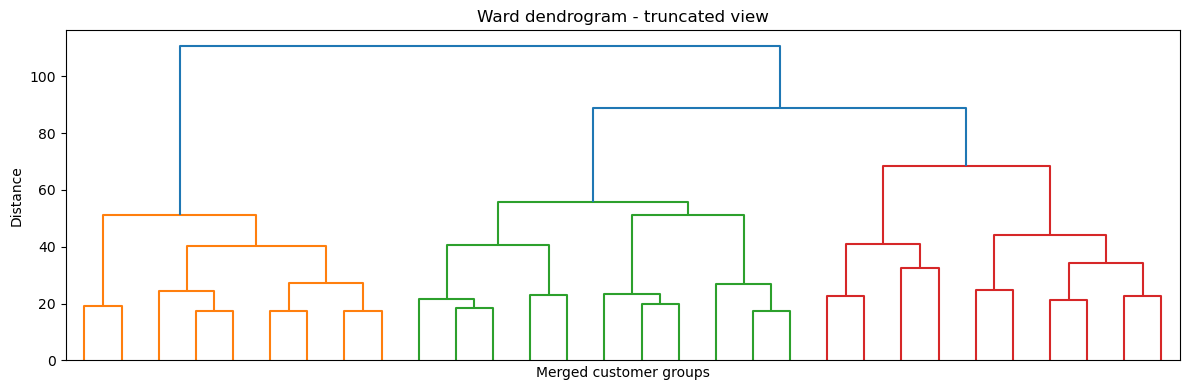

In [24]:
# Dendrogram for a visual check.
# I calculate it on the Ward sample and truncate the display to the last 30 merged groups.
try:
    from scipy.cluster.hierarchy import linkage, dendrogram

    Z = linkage(X_hier, method="ward")

    plt.figure(figsize=(12, 4))
    dendrogram(Z, truncate_mode="lastp", p=30, no_labels=True, color_threshold=None)
    plt.title("Ward dendrogram - truncated view")
    plt.xlabel("Merged customer groups")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Dendrogram skipped:", e)

---
## 11. Stability checks
Seeds test optimizer stability. Subsamples and holdout are better evidence that the structure is not too fragile.

In [25]:
# Stability across random seeds.
seed_rows = []
for seed in [7, 21, 42, 100, 2026]:
    model_seed, labels_seed = fit_kmeans(X_main_scaled, n_clusters=SELECTED_K, n_init=20, random_state=seed)
    seed_rows.append({
        "seed": seed,
        "inertia": model_seed.inertia_,
        "silhouette": silhouette_score(X_main_scaled, labels_seed),
        "ari_vs_final": adjusted_rand_score(kmeans_labels, labels_seed)
    })

seed_stability = pd.DataFrame(seed_rows).round(4)
mean_seed_ari = seed_stability["ari_vs_final"].mean()
display(seed_stability)
print("Note: high seed ARI mainly means the optimization is stable with n_init=20.")

,seed,inertia,silhouette,ari_vs_final
0,7,59745.8691,0.2214,0.9975
1,21,59745.5816,0.2212,0.9983
2,42,59745.8691,0.2214,0.9975
3,100,59745.9278,0.2210,0.9943
4,2026,59745.5321,0.2212,0.9988


Note: high seed ARI mainly means the optimization is stable with n_init=20.


In [26]:
# Stability across 80% subsamples.
subsample_rows = []
n_main = X_main_scaled.shape[0]
subsample_fraction = 0.80

for seed in [1, 2, 3, 4, 5]:
    rng = np.random.default_rng(seed)
    positions = rng.choice(np.arange(n_main), size=int(subsample_fraction * n_main), replace=False)
    X_sub = X_main_scaled[positions]
    final_labels_sub_positions = kmeans_labels[positions]

    model_sub, labels_sub = fit_kmeans(X_sub, n_clusters=SELECTED_K, n_init=20, random_state=seed)

    subsample_rows.append({
        "seed": seed,
        "subsample_size": len(positions),
        "silhouette": silhouette_score(X_sub, labels_sub),
        "ari_vs_final_on_same_rows": adjusted_rand_score(final_labels_sub_positions, labels_sub)
    })

subsample_stability = pd.DataFrame(subsample_rows).round(4)
mean_subsample_ari = subsample_stability["ari_vs_final_on_same_rows"].mean()
display(subsample_stability)

,seed,subsample_size,silhouette,ari_vs_final_on_same_rows
0,1,5728,0.2221,0.9865
1,2,5728,0.2225,0.9777
2,3,5728,0.2236,0.9862
3,4,5728,0.2202,0.9890
4,5,5728,0.2205,0.9884


In [27]:
# Holdout check: assign holdout using the fitted final KMeans model.
holdout_labels = kmeans_final.predict(X_holdout_scaled)

main_share = pd.Series(kmeans_labels).value_counts(normalize=True).sort_index()
holdout_share = pd.Series(holdout_labels).value_counts(normalize=True).sort_index()

holdout_stability = pd.DataFrame({
    "main_share": main_share,
    "holdout_share": holdout_share
}).fillna(0)
holdout_stability["absolute_difference"] = (holdout_stability["main_share"] - holdout_stability["holdout_share"]).abs()

display(holdout_stability.round(4))

,main_share,holdout_share,absolute_difference
0,0.3662,0.3642,0.0020
1,0.2568,0.2726,0.0158
2,0.1486,0.1419,0.0067
3,0.2284,0.2212,0.0071


---
## 12. Cluster profiles
Business profile is shown in real original units. Z-scores show what defines the clusters in the model space.

In [28]:
# Business profile in real original units, not log-transformed.
business_profile_cols = feature_cols_full
business_profile_main = X_main_raw[business_profile_cols].copy()
business_profile_main = business_profile_main.fillna(business_profile_main.median(numeric_only=True))
business_profile_main["cluster"] = kmeans_labels

business_profile_mean = business_profile_main.groupby("cluster").mean().round(2)
business_profile_median = business_profile_main.groupby("cluster").median().round(2)

print("Cluster means - original units")
display(business_profile_mean)

print("Cluster medians - original units")
display(business_profile_median)

# Z-score profile: stronger for understanding separation in the actual clustering space.
profile_z = pd.DataFrame(X_main_scaled, columns=feature_cols, index=X_main_raw.index)
profile_z["cluster"] = kmeans_labels
z_cluster_profile = profile_z.groupby("cluster").mean().round(2)

print("Cluster means - z-score model space")
display(z_cluster_profile)

Cluster means - original units


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,2424.00,0.95,212.36,174.31,38.12,2013.40,0.11,0.07,0.04,0.27,6.72,2.15,4381.22,1782.45,1134.32,0.03,11.42
1,2128.07,0.98,2734.07,1846.36,887.86,738.29,0.86,0.59,0.57,0.09,2.40,37.59,6559.85,2958.33,986.27,0.19,11.85
2,71.59,0.42,345.67,237.09,108.64,169.24,0.27,0.10,0.17,0.03,0.56,4.26,3665.38,787.80,146.76,0.20,11.27
3,553.40,0.94,705.22,62.42,643.32,147.45,0.82,0.04,0.77,0.03,0.53,15.44,3048.95,885.17,677.79,0.29,11.48


Cluster medians - original units


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,1637.01,1.00,0.00,0.00,0.0,1151.66,0.00,0.00,0.00,0.25,4.0,0.0,3000.0,851.62,547.19,0.00,12.0
1,1258.08,1.00,1814.64,1108.54,467.5,0.00,1.00,0.58,0.67,0.00,0.0,26.0,6000.0,1878.61,419.78,0.00,12.0
2,22.32,0.36,173.36,0.00,0.0,0.00,0.18,0.00,0.00,0.00,0.0,3.0,2500.0,302.96,122.22,0.00,12.0
3,158.63,1.00,493.32,0.00,438.8,0.00,0.92,0.00,0.83,0.00,0.0,12.0,2000.0,578.15,178.00,0.08,12.0


Cluster means - z-score model space


,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,
0,0.62,0.32,-0.38,-0.86,0.82,-0.94,-0.44,-0.81,0.69,-0.02,0.10,0.44,-0.43,-0.08
1,0.40,0.43,1.15,0.63,-0.25,0.92,1.32,0.52,-0.21,0.57,0.54,0.25,0.12,0.25
2,-1.51,-1.93,-0.15,-0.33,-0.57,-0.55,-0.35,-0.49,-0.53,-0.26,-0.88,-1.04,0.16,-0.19
3,-0.46,0.26,-0.59,0.88,-0.66,0.83,-0.54,1.03,-0.54,-0.44,-0.20,-0.31,0.45,-0.03


In [29]:
def top_defining_features(z_profile, top_n=5):
    rows = []
    for cluster_id, row in z_profile.iterrows():
        top_features = row.abs().sort_values(ascending=False).head(top_n).index
        for feature in top_features:
            rows.append({
                "cluster": cluster_id,
                "feature": feature,
                "z_mean": row[feature],
                "direction": "above average" if row[feature] > 0 else "below average"
            })
    return pd.DataFrame(rows)

defining_features = top_defining_features(z_cluster_profile, top_n=6)
display(defining_features)

,cluster,feature,z_mean,direction
0,0,PURCHASES_FREQUENCY,-0.94,below average
1,0,INSTALLMENTS_PURCHASES,-0.86,below average
2,0,CASH_ADVANCE,0.82,above average
3,0,PURCHASES_INSTALLMENTS_FREQUENCY,-0.81,below average
4,0,CASH_ADVANCE_FREQUENCY,0.69,above average
5,0,BALANCE,0.62,above average
6,1,ONEOFF_PURCHASES_FREQUENCY,1.32,above average
7,1,ONEOFF_PURCHASES,1.15,above average
8,1,PURCHASES_FREQUENCY,0.92,above average
9,1,INSTALLMENTS_PURCHASES,0.63,above average


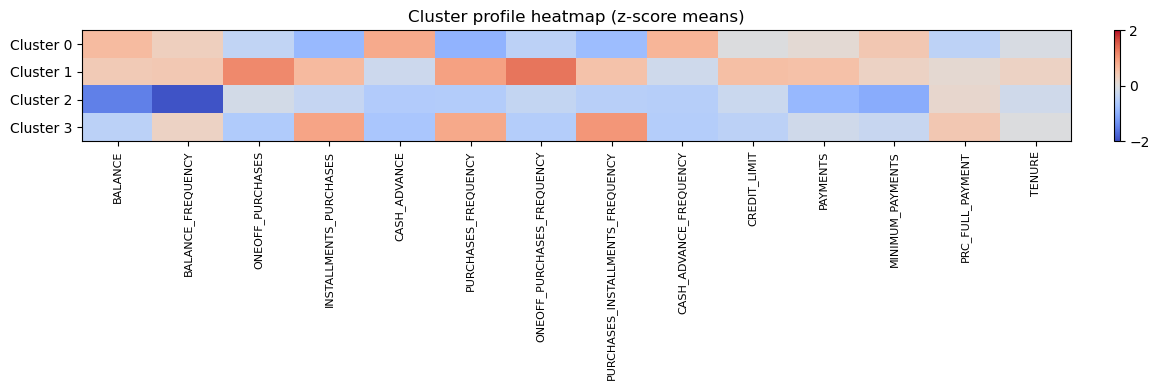

In [30]:
# Compact heatmap of cluster z-profiles.
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(z_cluster_profile.values, aspect="auto", vmin=-2, vmax=2, cmap="coolwarm")
ax.set_xticks(range(len(z_cluster_profile.columns)))
ax.set_xticklabels(z_cluster_profile.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(z_cluster_profile.index)))
ax.set_yticklabels(["Cluster " + str(c) for c in z_cluster_profile.index])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Cluster profile heatmap (z-score means)")
plt.tight_layout()
plt.show()

---
## 13. Personas and actions
These are draft names. I still review them against the profile table before submitting.

In [31]:
def val(row, feature):
    return float(row[feature]) if feature in row.index else 0.0


def suggest_persona_and_action(row):
    cash_score = max(val(row, "CASH_ADVANCE"), val(row, "CASH_ADVANCE_FREQUENCY"))
    oneoff_score = max(val(row, "ONEOFF_PURCHASES"), val(row, "ONEOFF_PURCHASES_FREQUENCY"))
    installment_score = max(val(row, "INSTALLMENTS_PURCHASES"), val(row, "PURCHASES_INSTALLMENTS_FREQUENCY"))
    balance_score = max(val(row, "BALANCE"), val(row, "MINIMUM_PAYMENTS"))
    payment_score = max(val(row, "PAYMENTS"), val(row, "PRC_FULL_PAYMENT"))
    purchase_freq_score = val(row, "PURCHASES_FREQUENCY")

    if cash_score > 0.75 and purchase_freq_score < 0:
        return (
            "High-balance non-purchasers with cash-advance use",
            "Monitor risk and offer cheaper repayment or credit-planning options."
        )
    if cash_score > 0.75:
        return (
            "Cash-advance users",
            "Review risk and offer cheaper repayment or credit-planning options."
        )
    if oneoff_score > 0.75 and oneoff_score >= installment_score:
        return (
            "Large one-off purchase customers",
            "Offer targeted rewards around large purchases and premium card usage."
        )
    if installment_score > 0.75:
        return (
            "Installment-oriented purchasers",
            "Promote structured installment offers and merchant campaigns."
        )
    if balance_score > 0.65 and payment_score < 0.30:
        return (
            "Revolving balance customers",
            "Monitor credit risk and nudge higher monthly payments."
        )
    if purchase_freq_score < -0.40 and payment_score < 0.40:
        return (
            "Low activity customers",
            "Use low-cost digital activation offers before spending retention budget."
        )
    return (
        "Low-to-moderate general users",
        "Keep as a broad base segment; split further only if a campaign needs it."
    )

segment_rows = []
for cluster_id, row in z_cluster_profile.iterrows():
    persona, action = suggest_persona_and_action(row)
    cluster_feats = defining_features[defining_features["cluster"] == cluster_id].copy()

    # Put positive drivers first, then the strongest below-average features.
    pos_feats = cluster_feats[cluster_feats["z_mean"] > 0].head(2)
    neg_feats = cluster_feats[cluster_feats["z_mean"] <= 0].head(2)
    chosen_feats = pd.concat([pos_feats, neg_feats]).head(4)

    feat_text = ", ".join([
        f"{r.feature} ({r.direction})" for r in chosen_feats.itertuples(index=False)
    ])
    segment_rows.append({
        "cluster": cluster_id,
        "share": float(cluster_shares.loc[cluster_id]),
        "suggested_persona": persona,
        "defining_features": feat_text,
        "business_action": action
    })

segment_card = pd.DataFrame(segment_rows).sort_values("cluster")
display(segment_card)

,cluster,share,suggested_persona,defining_features,business_action
0,0,0.3662,High-balance non-purchasers with cash-advance use,"CASH_ADVANCE (above average), CASH_ADVANCE_FRE...",Monitor risk and offer cheaper repayment or cr...
1,1,0.2568,Large one-off purchase customers,"ONEOFF_PURCHASES_FREQUENCY (above average), ON...",Offer targeted rewards around large purchases ...
2,2,0.1486,Low activity customers,"BALANCE_FREQUENCY (below average), BALANCE (be...",Use low-cost digital activation offers before ...
3,3,0.2284,Installment-oriented purchasers,PURCHASES_INSTALLMENTS_FREQUENCY (above averag...,Promote structured installment offers and merc...


---
## 14. Artifact checks
This is the honest part: the clusters are useful only if they are not just a side effect of scaling, k, or the algorithm.

In [32]:
weakest_cluster = int(sil_by_cluster["avg_silhouette"].idxmin())
weakest_cluster_avg_sil = float(sil_by_cluster.loc[weakest_cluster, "avg_silhouette"])
weakest_cluster_neg_pct = float(sil_by_cluster.loc[weakest_cluster, "pct_negative"])

artifact_checks = pd.DataFrame({
    "check": [
        "Final Silhouette",
        "Smallest cluster share",
        "Largest cluster share",
        "Ward vs KMeans ARI",
        "Mean seed ARI",
        "Mean subsample ARI",
        "Max holdout share difference",
        "Weakest cluster",
        "Weakest cluster avg Silhouette",
        "Weakest cluster negative share"
    ],
    "value": [
        final_silhouette,
        float(cluster_shares.min()),
        float(cluster_shares.max()),
        hier_vs_kmeans_ari,
        mean_seed_ari,
        mean_subsample_ari,
        float(holdout_stability["absolute_difference"].max()),
        weakest_cluster,
        weakest_cluster_avg_sil,
        weakest_cluster_neg_pct
    ]
})

display(artifact_checks.round(4))

if hier_vs_kmeans_ari < 0.40:
    print("Note: Ward and KMeans do not strongly agree. I should frame the result as practical segmentation, not proven natural groups.")
if cluster_shares.max() > 0.60:
    print("Note: one cluster is still very large. It may be an 'everyone else' segment.")
if weakest_cluster_avg_sil < 0.15:
    print(f"Note: Cluster {weakest_cluster} is the weakest segment and should be treated as tentative.")

,check,value
0,Final Silhouette,0.2212
1,Smallest cluster share,0.1486
2,Largest cluster share,0.3662
3,Ward vs KMeans ARI,0.5683
4,Mean seed ARI,0.9973
5,Mean subsample ARI,0.9856
6,Max holdout share difference,0.0158
7,Weakest cluster,2.0000
8,Weakest cluster avg Silhouette,0.1198
9,Weakest cluster negative share,0.1945


Note: Cluster 2 is the weakest segment and should be treated as tentative.


---
## 15. Short report draft
Generated draft only. I will still edit it in my own words.

In [33]:
def make_structure_card():
    lines = []
    lines.append("STRUCTURE CARD — Credit Card Behavioral Segmentation")
    lines.append("Final preprocessing: " + FINAL_SETUP_NAME)
    lines.append("Final k: " + str(SELECTED_K))
    lines.append("Silhouette: " + str(round(final_silhouette, 4)))
    lines.append("Ward vs KMeans ARI: " + str(round(hier_vs_kmeans_ari, 4)))
    lines.append("")
    for _, row in segment_card.iterrows():
        lines.append(
            "Cluster {0} | {1:.1%} | {2} | Defined by: {3} | Action: {4}".format(
                int(row["cluster"]),
                row["share"],
                row["suggested_persona"],
                row["defining_features"],
                row["business_action"]
            )
        )
    return "\n".join(lines)

structure_card_text = make_structure_card()
print(structure_card_text)


STRUCTURE CARD — Credit Card Behavioral Segmentation
Final preprocessing: reduced_log_scaled
Final k: 4
Silhouette: 0.2212
Ward vs KMeans ARI: 0.5683

Cluster 0 | 36.6% | High-balance non-purchasers with cash-advance use | Defined by: CASH_ADVANCE (above average), CASH_ADVANCE_FREQUENCY (above average), PURCHASES_FREQUENCY (below average), INSTALLMENTS_PURCHASES (below average) | Action: Monitor risk and offer cheaper repayment or credit-planning options.
Cluster 1 | 25.7% | Large one-off purchase customers | Defined by: ONEOFF_PURCHASES_FREQUENCY (above average), ONEOFF_PURCHASES (above average) | Action: Offer targeted rewards around large purchases and premium card usage.
Cluster 2 | 14.9% | Low activity customers | Defined by: BALANCE_FREQUENCY (below average), BALANCE (below average) | Action: Use low-cost digital activation offers before spending retention budget.
Cluster 3 | 22.8% | Installment-oriented purchasers | Defined by: PURCHASES_INSTALLMENTS_FREQUENCY (above average), I

In [35]:
# Save a short report draft next to the notebook.
segment_lines = []
for _, row in segment_card.iterrows():
    segment_lines.append(
        "- Cluster {0}: {1} ({2:.1%}). Main drivers: {3}. Action: {4}".format(
            int(row["cluster"]),
            row["suggested_persona"],
            row["share"],
            row["defining_features"],
            row["business_action"]
        )
    )

report_text = f"""# REPORT — Module 3 · Assignment 2 · Unsupervised Learning

**Name:** ___ 
**Chosen option:** B · Credit Card behavioral segmentation

---

## 1. Framing
I looked for behavioral customer segments in credit card usage data. The business goal is to support different marketing, risk, and activation actions for different customer types.

Distance measure: Euclidean distance after preprocessing. I used it because KMeans and Ward clustering are distance-based, and the features are numeric. Many variables were skewed and correlated, so I compared raw scaling with log-based preprocessing and used a reduced log-based feature set.

---

## 2. Method & validation

| Item | Value |
|---|---|
| Approaches tried | KMeans + Ward hierarchical clustering |
| Final preprocessing | {FINAL_SETUP_NAME} |
| Chosen k | {SELECTED_K} |
| Silhouette score | {final_silhouette:.4f} |
| Ward vs KMeans ARI | {hier_vs_kmeans_ari:.4f} |
| Mean subsample ARI | {mean_subsample_ari:.4f} |
| Largest holdout share difference | {holdout_stability['absolute_difference'].max():.4f} |
| Weakest cluster | Cluster {weakest_cluster} |

---

## 3. Guiding questions

1. **No ground truth.** I judged the clustering using internal metrics, cluster sizes, stability checks, PCA visualization, and whether the profiles made business sense. This evidence is limited because there are no labels proving that these are the true customer groups.

2. **Choosing k.** In the final setup, Elbow and Silhouette both supported k={SELECTED_K}. I also preferred it because it avoided one broad “everyone else” cluster and gave more usable business segments.

3. **Scaling.** Scaling changed the distance space and the resulting clusters. The unscaled Silhouette is not directly comparable because it is measured in a different space and is dominated by large monetary columns.

4. **Stability.** Seed stability was high, but that mainly shows the optimizer is stable. The better evidence is the subsample and holdout checks, which test whether similar structure appears when the data changes.

5. **What defines each cluster.** The main separating features are shown in the segment card. Overall, the clusters are separated by purchase behavior, cash advances, balance/payment behavior, and activity level.

6. **Real or artifact.** Ward and KMeans had moderate agreement, so the result is not completely algorithm-independent. Cluster {weakest_cluster} is the weakest segment by Silhouette and should be treated as more tentative than the others.

7. **Action.** Each segment has one suggested business action below. If a segment is too broad or unstable, it should be used carefully or split further for a specific campaign.

8. **Cost of a false alarm.** For clustering, the risk is targeting customers with the wrong action. That can waste campaign budget or create a bad customer experience, so the segments should support decisions rather than automate them blindly.

---

## 4. Structure Card

```text
{structure_card_text}
```

---

## 5. Reflection
The main surprise was how much preprocessing mattered. Standard scaling alone was not enough because the data had strong skewness and redundant behavior variables. I would trust the segments as a useful first business view, but I would validate them on newer data before using them for a real campaign.
"""

with open("REPORT_DRAFT_Unsupervised_v6.md", "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved: REPORT_DRAFT_Unsupervised_v6.md")

Saved: REPORT_DRAFT_Unsupervised_v6.md
